## Tutorial: Measure flowers and coverage with PlantCV-Geospatial

This tutorial uses PlantCV-Geospatial v1.0. Last updated July 25, 2026. You must have PlantCV and PlantCV-Geospatial installed to use this tutorial. For installation instructions, visit [this page for PlantCV](https://docs.plantcv.org/en/stable/installation/) and [this page for PlantCV Geospatial](https://docs.plantcv.org/projects/geospatial/en/latest/installation/). 

This tutorial is an example workflow for measuring flowers in UAV images based on color. This will cover basics of:
  - Reading in images with `plantcv-geospatial` (`gcv`)
  - Using the `InteractiveShapes` class to annotate images and draw plant/plot boundaries.
  - Adjust plot boundaries for irregularly planted plants/plots. 
  - Threshold (aka mask or segment) objects in an image using a binary threshold based on color. 
  - Flower detection and flower coverage per plant/plot based on the binary mask. 

## Step 1: Load in packages and specify parameters

First, we load `plantcv.geospatial`. Here we also load the main `plantcv.plantcv.` package so that we can set our debug parameter and for checking our `outputs` class later.

In [1]:
#Import libraries necessary for PlantCV-Geospatial
%matplotlib widget
from plantcv import geospatial as gcv
from plantcv import plantcv as pcv
pcv.params.debug = "plot"

# Check that PlantCV and PlantCV-Geospatial were loaded properly by checking the version
print(pcv.__version__)
print(gcv.__version__)

5.0.0rc1
0.1.dev1261+ge44320753


## Step 2: Import (aka read) in an image. 
With our parameters set we are ready to read in an image.

`gcv.read` currently supports `.geotif` and select `.netcdf` files (as more accepted standards come out of the netcdf format we may expand to include more supported types there).

[`gcv.read.geotif`](https://docs.plantcv.org/projects/geospatial/en/latest/read_geotif/#) is used here to read in a grayscale `.tif` file. There are four arguments to `read.geotif`:
- 1: 'filename': The path to a file
- 2: 'bands': Bands to read, defaults to "R,G,B" but supports R, G, B, RE, N, NIR, and GRAY.
- 3: 'cropto': Defaults to None but can be a path to a shapefile to crop the image to.
- 4: 'cutoff': Defaults to None but can be a percentile above which to remove points in grayscale images.

In [2]:
# Read in image

img = gcv.read.geotif(filename="./img/Flowering_tutorial_cropped.tif", bands="b,g,r,re,nir,mask")

RuntimeError: Currently mask is not supported, instead provide list of wavelengths in order.

# Step 3: Cast image into grayscale to create a mask
Using main PlantCV, convert the image thumbnail into grayscale to begin creating a mask of Silphium flowers. First, cast the image into 10 colorspaces using [*pcv.visualize.colorspaces*](https://docs.plantcv.org/en/stable/visualize_colorspace/). 

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-40.816406..347.11368].


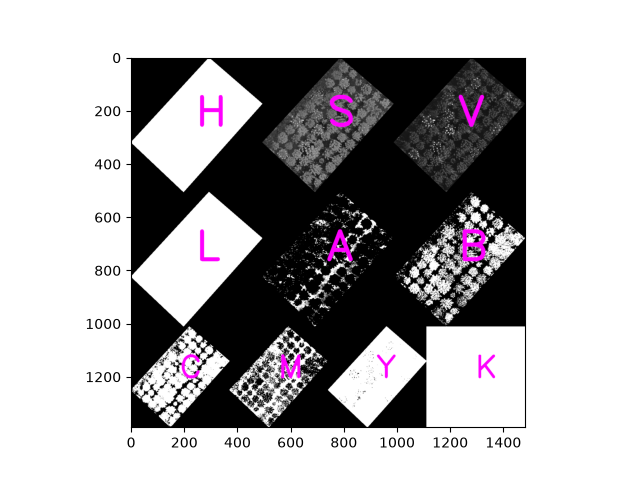

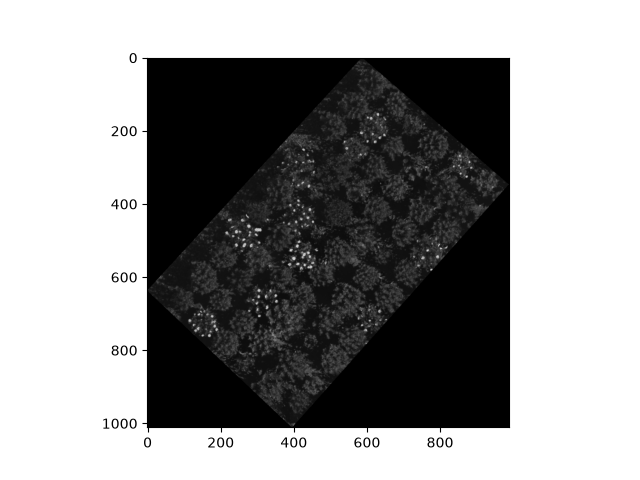

In [ ]:
# Enlarge the text so it is more readable
pcv.params.text_size = 10
pcv.params.text_thickness = 30

# Identify which colorspace creates the greatest flower-to-plant contrast
pcv.visualize.colorspaces(rgb_img=img.thumb, original_img=False)

Observe how the **V channel** contrasts the flowers from the background. Convert the image to grayscale through the chosen channel using [*pcv.rgb2gray_hsv*](https://docs.plantcv.org/en/stable/rgb2hsv/). 

In [ ]:
# Cast the image into the chosen channel
gray_v = pcv.rgb2gray_hsv(rgb_img=img.thumb, channel="v")

# Step 4: Threshold grayscale image to create a binary mask
Visualize the distribution of pixel intensities in the grayscale image. Next create a list of a few values to test as possible thresholds for the binary mask using [*pcv.threshold.binary*](https://docs.plantcv.org/en/stable/binary_threshold/). Look for where most of the remaining pixels resemble flower color.

alt.Chart(...)

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2745649].


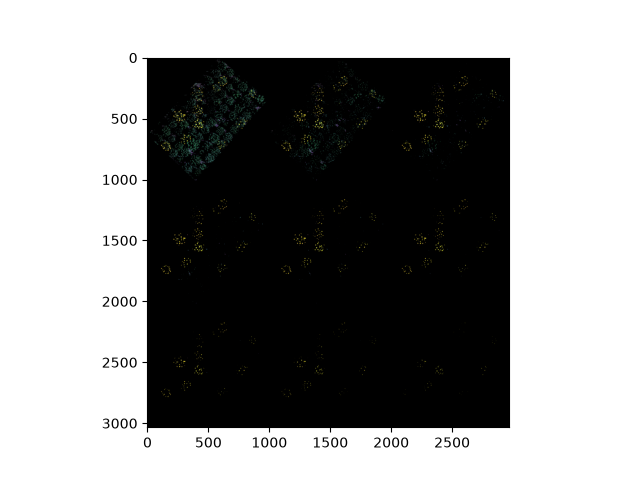

In [ ]:
# Display histogram to visualize grayscale values for thresholding
pcv.visualize.histogram(img=gray_v)

# Cycle through some values for the thresholding and look at them
threshvals = [0.25, 0.35, 0.45, 0.55, 0.65, 0.75, 0.85, 0.95, 1.0]
pcv.params.debug = None

# Create a list to pass threshold values through for testing
masked_list = []
for i in threshvals:
    mask = pcv.threshold.binary(gray_v, threshold=i)
    masked = pcv.apply_mask(img.thumb, mask, mask_color="black")
    masked_list.append(masked)

pcv.params.debug = "plot"

# Shows all thresholded outputs in a tiled graphic for easier comparison
tiled = pcv.visualize.tile(masked_list, ncol=3)

In this example, like the threshold value of **0.55** provides the best coverage for flowers and separates them well from the background and other parts of the plant. This will be the threshold value to use for the mask. 

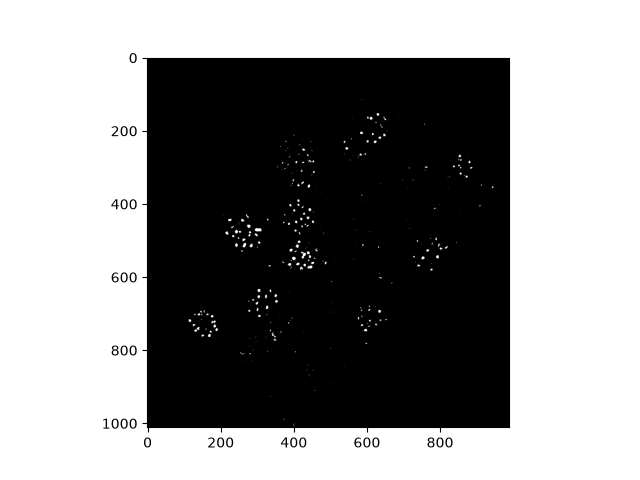

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.0..1.2745649].


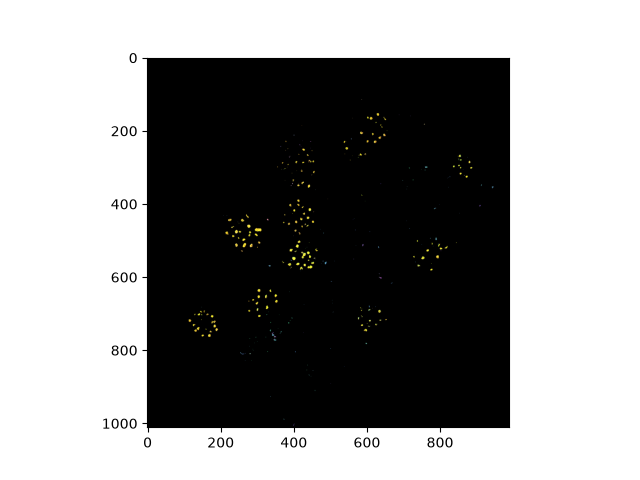

In [ ]:
# Create a mask using the threshold value that best separates the flowers from the plant
mask = pcv.threshold.binary(gray_v, threshold=0.55)

# Apply the mask to the original image to isolate the flowers
masked = pcv.apply_mask(img.thumb, mask, mask_color="black")

# Step 5: Create the field boundary
Create the boundary using the autogrid method on an InteractiveShapes Object. Use different methods in [*gcv.create_shapes.InteractiveShapes*](https://docs.plantcv.org/projects/geospatial/en/latest/InteractiveShapes/) to set up the boundaries in the image. Using the `Add Polygon` tool (highlighted in the image below), draw a tight rectangle around the edges of the entire field, starting in the upper left corner, in the `field_boundary` layer once the napari window opens. Once you have selected the 4 points for your rectangle, press the `Enter` key to finalize the polygon.

![image.png](attachment:6a7c13f6-5443-4e15-bc04-d3ca47d77713.png)

In [ ]:
# Load the napari viewer to add the field boundary layer

editor = gcv.create_shapes.InteractiveShapes(img, field_layer="field_boundary")

# Step 6: Create plant/plot boundaries with autogrid method
Once the rectangle is drawn around the field in the `field_boundary` layer, automatically draw a grid of lines to outline individual plots using the `grid` method. Adjust **[columns, ranges]** in `numdivs` if they are off until plots are covered. See example image of the napari viewer. 

![image.png](attachment:0190ba87-1096-4154-a586-6a39cd63c726.png)

In [ ]:
# Load the napari viewer to add the field boundary layer and set the grid to 11 columns and 6 rows. 
# This field was planted with 11 rows and 6 columns. Each plant is considered an individual plot in this example. 

editor.grid(numdivs=[11,6])

NameError: name 'editor' is not defined

# Step 7: Adjust the plant/plot boundaries
Adjust the gridlines using the `Select vertices` tool in napari (see image below) to more precisely have plot boundaries. This is particularly important tool in cases were fields were not planted in straight grids. After adjusting the gridlines, draw polygons using the line intersections using the `plots` method.

In [ ]:
# Load the napari viewer to add the field boundary layer and correct the lines until they enclose individual plots. Draw polygons using the line intersections. You can edit the polygon vertices if they are still not perfect.

editor.plots()

# Step 8: Save plot boundaries to a file

After boundaries have been adjusted, save them to a file. 

In [ ]:
# Save the plot boundaries to a file

plots = editor.to_shapes(dest="./plots.geojson", layername="Plots")

# Step 9: Estimate flower coverage in each plot

Use the mask and plot boundaries to estiamte the coverage of each plot area in flowers. If the flowers are the same size, the number of flower pixels may correlate with the number of flowers. 

/Users/pbhatt/miniforge3/envs/plantcv/lib/python3.12/site-packages/rasterstats/io.py:437: NodataWarning: Setting nodata to -999; specify nodata explicitly
  warnings.warn(
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.011026782..1.2745649].


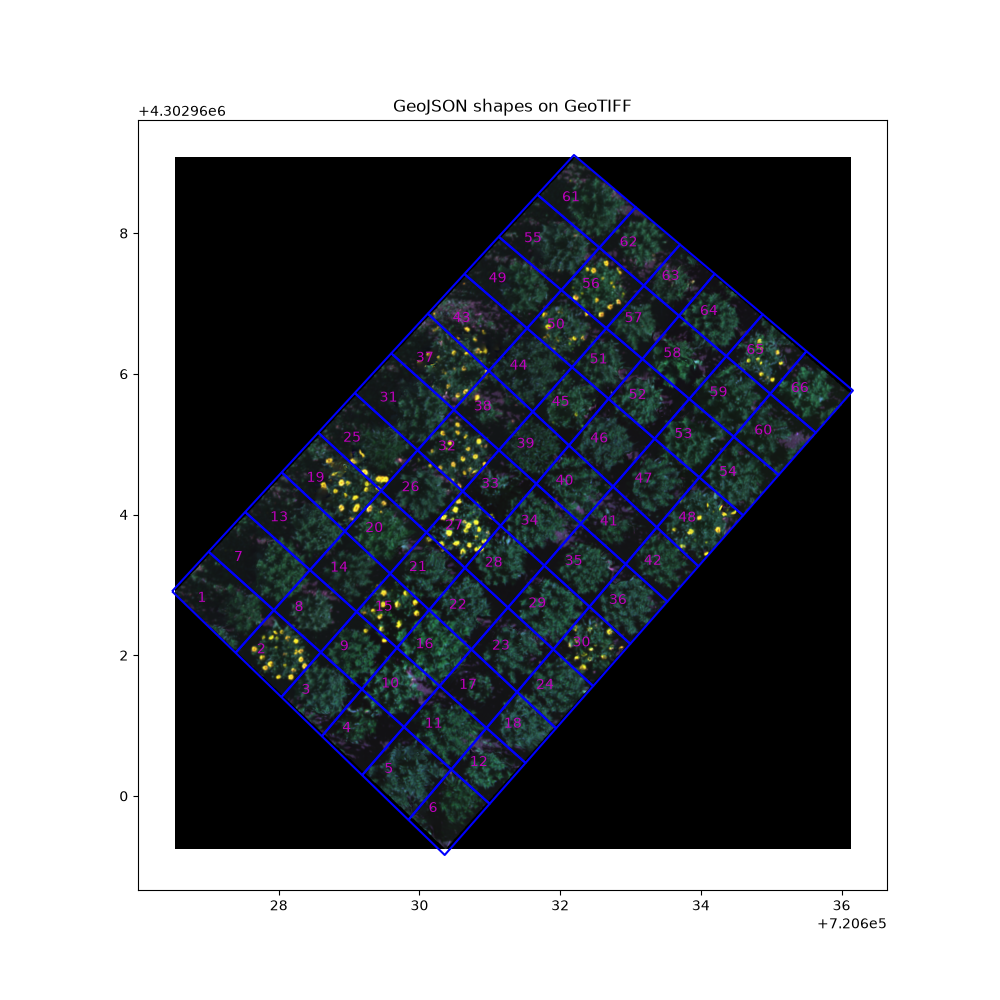

In [ ]:
# Use the analyze.coverage function to determine the percent cover of the mask in each plot. 

cov = gcv.analyze.coverage(img, mask, geojson="./plots.geojson")

## Step 10: Save the results

In [ ]:
# Save results to a csv file for further analysis in Excel or R. 
# The csv file will contain the plot ID, the number of pixels in the mask, and the percent coverage of the mask in each plot.

pcv.outputs.save_results(filename="./coverage_results.csv", outformat="csv")